# Cost of Delay — an ordering is not a schedule

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/cost-of-delay/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/cost-of-delay/demo.ipynb)

Somebody asks what to do first. So you score the backlog — RICE, or WSJF, or
cost-of-delay-divided-by-duration — and you get a ranked list. The list is the
deliverable and the meeting ends.

But a list is not what you pay. You pay for the **schedule** the list produces:
the week each item actually ships, multiplied by what each week of not having it
costs. This notebook prices both, over **every one of the 362,880 orderings** of a
nine-item backlog, so the gap between the ordering and the schedule is measured
rather than argued about.

**What is in here**

1. A nine-item backlog, and cost of delay modelled as a *rate over time*
2. Why a single "cost of delay per week" number throws away the answer
3. WSJF is *exactly* optimal — Smith's rule, 1956 — and the four conditions it needs
4. "CD3" does not name an ordering: one input, three defensible elicitations
5. Four of nine methods lose to drawing the backlog out of a hat
6. Nobody schedules to the fixed date
7. Two teams: the condition you can safely ignore
8. The rank is noise. The cost is not.

Everything runs on numpy and the standard library. No API keys, no data files.

## 1. Cost of delay is a rate, not a number

Every prioritisation method wants one number per item: "what does a week of delay
cost us?" That question has an answer only if the cost is *constant over time*.

Four shapes cover almost every real item:

| shape | rate over time | what it is in the world |
|---|---|---|
| `linear` | constant `r` | revenue you are not yet earning |
| `deadline` | 0, then `r2` after a date | an audit, a regulation, a contract |
| `step` | `r`, then `r2` after a date | a clause that bites at renewal |
| `window` | `r` decaying with constant `tau` | a market opening that closes |

What lands on the P&L is the **integral** of that rate up to the week the thing
ships. That integral is the only quantity worth optimising, and it is the one
nobody writes down.

In [1]:
from __future__ import annotations

import itertools
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Sequence, Tuple

HORIZON = 40.0  # weeks


@dataclass(frozen=True)
class CoD:
    """Cost of delay as a rate over time. `cum(c)` = total cost of shipping at week c."""
    kind: str
    r: float = 0.0
    r2: float = 0.0
    tau: float = 0.0
    t_break: float = 0.0

    def rate(self, t: float) -> float:
        if self.kind == "linear":
            return self.r
        if self.kind == "deadline":
            return 0.0 if t < self.t_break else self.r2
        if self.kind == "step":
            return self.r if t < self.t_break else self.r2
        return self.r * math.exp(-t / self.tau)          # window

    def cum(self, c: float) -> float:
        if c <= 0.0:
            return 0.0
        if self.kind == "linear":
            return self.r * c
        if self.kind == "deadline":
            return self.r2 * max(0.0, c - self.t_break)
        if self.kind == "step":
            return self.r * min(c, self.t_break) + self.r2 * max(0.0, c - self.t_break)
        return self.r * self.tau * (1.0 - math.exp(-c / self.tau))   # window

    def mean_rate(self, horizon: float = HORIZON) -> float:
        return self.cum(horizon) / horizon

    def peak_rate(self, horizon: float = HORIZON) -> float:
        return max(self.rate(horizon * i / 400.0) for i in range(401))


print("linear 38/wk shipped at week 20 :", CoD("linear", r=38).cum(20))
print("deadline 180/wk after week 26   :", CoD("deadline", r2=180, t_break=26).cum(20),
      "->", CoD("deadline", r2=180, t_break=26).cum(40))

linear 38/wk shipped at week 20 : 760
deadline 180/wk after week 26   : 0.0 -> 2520


## 2. The backlog

Nine items, forty weeks of work for one team, cost of delay in $k per week.

Two columns that are usually conflated: `duration` is **calendar weeks** for one
team, and `person_weeks` is **effort**. Delay is paid in calendar weeks. RICE's
denominator is effort. Hold that thought until section 5.

In [2]:
@dataclass(frozen=True)
class Item:
    key: str
    name: str
    duration: float        # calendar weeks - what delay is paid in
    person_weeks: float    # effort - what estimates are given in
    cod: CoD
    reach: float
    impact: float
    confidence: float

    @property
    def rice(self) -> float:
        return self.reach * self.impact * self.confidence / (self.person_weeks / 4.0)

    @property
    def rice_duration_denominator(self) -> float:
        return self.reach * self.impact * self.confidence / (self.duration / 4.0)


RAW = [
    ("A", "sso-saml",          6, 12, CoD("linear", r=38.0),                       400, 3.0, 0.90),
    ("B", "soc2-evidence",     4,  4, CoD("deadline", r2=180.0, t_break=26.0),     150, 2.0, 0.80),
    ("C", "usage-billing",     8,  8, CoD("linear", r=52.0),                       900, 2.0, 0.80),
    ("D", "onboarding-revamp", 3,  6, CoD("window", r=70.0, tau=10.0),            2000, 1.0, 0.90),
    ("E", "api-rate-limits",   2,  2, CoD("linear", r=9.0),                         300, 0.5, 1.00),
    ("F", "data-export",       1,  1, CoD("linear", r=6.0),                         250, 0.5, 1.00),
    ("G", "mobile-push",       5, 10, CoD("window", r=30.0, tau=25.0),            1500, 1.0, 0.60),
    ("H", "audit-log",         4,  4, CoD("step", r=5.0, r2=45.0, t_break=20.0),    200, 1.0, 0.90),
    ("I", "search-rebuild",    7,  7, CoD("linear", r=22.0),                       1800, 2.0, 0.50),
]
ITEMS = {k: Item(k, n, float(d), float(p), c, float(re), float(im), float(cf))
         for k, n, d, p, c, re, im, cf in RAW}

PRECEDENCE = (("H", "B"), ("E", "C"))   # audit log before its evidence; metering before billing

print(f"{'':3} {'item':20} {'dur':>4} {'p-wk':>5} {'shape':>9} {'rate@0':>7} "
      f"{'mean':>7} {'total@40':>9} {'RICE':>7}")
for k in sorted(ITEMS):
    it = ITEMS[k]
    print(f"{k:3} {it.name:20} {it.duration:4.0f} {it.person_weeks:5.0f} "
          f"{it.cod.kind:>9} {it.cod.rate(0):7.1f} {it.cod.mean_rate():7.1f} "
          f"{it.cod.cum(40):9.1f} {it.rice:7.0f}")
print(f"\ntotal duration {sum(i.duration for i in ITEMS.values()):.0f} weeks")

    item                  dur  p-wk     shape  rate@0    mean  total@40    RICE
A   sso-saml                6    12    linear    38.0    38.0    1520.0     360
B   soc2-evidence           4     4  deadline     0.0    63.0    2520.0     240
C   usage-billing           8     8    linear    52.0    52.0    2080.0     720
D   onboarding-revamp       3     6    window    70.0    17.2     687.2    1200
E   api-rate-limits         2     2    linear     9.0     9.0     360.0     300
F   data-export             1     1    linear     6.0     6.0     240.0     500
G   mobile-push             5    10    window    30.0    15.0     598.6     360
H   audit-log               4     4      step     5.0    25.0    1000.0     180
I   search-rebuild          7     7    linear    22.0    22.0     880.0    1029

total duration 40 weeks


### Read the `rate@0` and `total@40` columns side by side

`onboarding-revamp` is the most urgent thing in the backlog if you ask "what does
a week cost us right now": **70/week**, twice the next item.

`soc2-evidence` is the *least* urgent by the same question: **0/week**. Delay is
genuinely free — until week 26.

Over the full window the 0/week item costs **2520** and the 70/week item costs
**687**. The number the room produces has the ranking backwards, and it is not
because anyone estimated badly. It is because a rate at one instant cannot
represent a cost over an interval.

In [3]:
print(f"{'item':20} {'quoted':>13}   " +
      "  ".join(f"{'wk' + str(w):>8}" for w in (5, 10, 20, 30, 40)))
for k in ("D", "A", "H", "B"):
    it = ITEMS[k]
    cells = "  ".join(f"{it.cod.cum(w):8.1f}" for w in (5, 10, 20, 30, 40))
    print(f"{it.name:20} {it.cod.rate(0):8.1f}/wk   {cells}")

d = ITEMS["D"].cod
early, late = d.cum(10) - d.cum(0), d.cum(40) - d.cum(30)
print(f"\nSaturation: delaying onboarding-revamp weeks 0->10 costs {early:.1f}; "
      f"weeks 30->40 costs {late:.1f} ({early / late:.0f}x less).")
print("Urgency is not a property of the item. It is a property of when you are.")

item                        quoted        wk5      wk10      wk20      wk30      wk40
onboarding-revamp        70.0/wk      275.4     442.5     605.3     665.1     687.2
sso-saml                 38.0/wk      190.0     380.0     760.0    1140.0    1520.0
audit-log                 5.0/wk       25.0      50.0     100.0     550.0    1000.0
soc2-evidence             0.0/wk        0.0       0.0       0.0     720.0    2520.0

Saturation: delaying onboarding-revamp weeks 0->10 costs 442.5; weeks 30->40 costs 22.0 (20x less).
Urgency is not a property of the item. It is a property of when you are.


## 3. Scoring the schedule, not the list

One team, no interruption. Walk the order; each item finishes when the one before
it does plus its own duration. The cost of the *ordering* is the sum over items of
`cod.cum(finish_week)`.

This is the number every method in this notebook is judged on. It is also the
number none of them compute.

In [4]:
def completions(order: Sequence[str], items: Dict[str, Item]) -> Dict[str, float]:
    t, out = 0.0, {}
    for k in order:
        t += items[k].duration
        out[k] = t
    return out


def cost_of(order: Sequence[str], items: Dict[str, Item]) -> float:
    c = completions(order, items)
    return sum(items[k].cod.cum(c[k]) for k in order)


def rank(items: Dict[str, Item], score: Callable[[Item], float]) -> List[str]:
    """Descending by score, ties broken by key so results are reproducible."""
    return sorted(items, key=lambda k: (-score(items[k]), k))


ORDERINGS: Dict[str, Callable[[Dict[str, Item]], List[str]]] = {
    # WSJF / CD3, with cost of delay elicited three defensible ways
    "cd3_initial":    lambda it: rank(it, lambda x: x.cod.rate(0.0) / x.duration),
    "cd3_mean":       lambda it: rank(it, lambda x: x.cod.mean_rate() / x.duration),
    "cd3_peak":       lambda it: rank(it, lambda x: x.cod.peak_rate() / x.duration),
    "rice":           lambda it: rank(it, lambda x: x.rice),
    "rice_duration":  lambda it: rank(it, lambda x: x.rice_duration_denominator),
    "value_first":    lambda it: rank(it, lambda x: x.cod.cum(HORIZON)),
    "shortest_first": lambda it: rank(it, lambda x: -x.duration),
    "effort_first":   lambda it: rank(it, lambda x: -x.person_weeks),
    # the order the loudest stakeholder actually asked for
    "hippo":          lambda it: ["G", "D", "I", "A", "C", "F", "E", "H", "B"],
}

for name, f in ORDERINGS.items():
    o = f(ITEMS)
    print(f"{name:15} {''.join(o)}   {cost_of(o, ITEMS):8.1f}")

cd3_initial     DCAFGEIHB     6227.5
cd3_mean        BCAHFDEIG     3904.6
cd3_peak        BDHCAFGEI     4211.4
rice            DICFAGEBH     6013.5
rice_duration   DIACGFEBH     6040.3
value_first     BCAHIDGEF     3977.7
shortest_first  FEDBHGAIC     4552.1
effort_first    FEBHDICGA     4662.9
hippo           GDIACFEHB     6965.4


## 4. Every ordering, enumerated

Nine items is `9! = 362,880` orderings. That is small enough to price all of them,
which means three things stop being estimates:

- the **optimum** is the optimum, not a heuristic's best guess
- the **mean over all orderings** is exactly the expected cost of shuffling the
  backlog — the honest "do nothing thoughtful" baseline
- a method's **percentile** is exact: the share of orderings that beat it

In [5]:
def sweep(items: Dict[str, Item],
          edges: Optional[Sequence[Tuple[str, str]]] = None) -> Dict[str, object]:
    keys = sorted(items)
    durs = [items[k].duration for k in keys]
    cums = [items[k].cod.cum for k in keys]
    n = len(keys)
    best, worst, total, count = math.inf, -math.inf, 0.0, 0
    best_p = worst_p = tuple(range(n))
    for perm in itertools.permutations(range(n)):
        if edges:
            pos = {keys[i]: p for p, i in enumerate(perm)}
            if not all(pos[a] < pos[b] for a, b in edges):
                continue
        t = tot = 0.0
        for i in perm:
            t += durs[i]
            tot += cums[i](t)
        total += tot
        count += 1
        if tot < best:
            best, best_p = tot, perm
        if tot > worst:
            worst, worst_p = tot, perm
    return {"best": best, "best_order": [keys[i] for i in best_p],
            "worst": worst, "worst_order": [keys[i] for i in worst_p],
            "mean": total / count, "count": count}


def all_costs(items: Dict[str, Item]) -> List[float]:
    keys = sorted(items)
    durs = [items[k].duration for k in keys]
    cums = [items[k].cod.cum for k in keys]
    out = []
    for perm in itertools.permutations(range(len(keys))):
        t = tot = 0.0
        for i in perm:
            t += durs[i]
            tot += cums[i](t)
        out.append(tot)
    return out


SR = sweep(ITEMS)
COSTS = all_costs(ITEMS)
print(f"orderings priced      {SR['count']:,}")
print(f"optimum               {SR['best']:8.1f}   {''.join(SR['best_order'])}")
print(f"mean of all orderings {SR['mean']:8.1f}   <- shuffling the backlog")
print(f"worst possible        {SR['worst']:8.1f}   {''.join(SR['worst_order'])}")

orderings priced      362,880
optimum                 3288.5   CAEHFBIGD
mean of all orderings   4871.7   <- shuffling the backlog
worst possible          7162.0   IGEDFACHB


## 5. WSJF is optimal — and it needs four conditions

**Smith's rule (W. E. Smith, 1956):** on a single machine, minimising total
*weighted completion time* is achieved exactly by sequencing in decreasing order
of `weight / processing time`. No search, no heuristic — it is provably optimal.

That rule *is* CD3 / WSJF. So the method is not folklore; it has a theorem behind
it. The theorem's assumptions are the part that gets dropped:

1. delay cost is **linear** in time
2. **one** machine
3. **no** release dates or deadlines
4. **no** precedence constraints

Below: linearise the cost shapes (same total value over the window, constant rate)
and the theorem reproduces the exhaustive optimum exactly. Then put the real
shapes back, change nothing else, and watch the gap open.

In [6]:
def linearised(items: Dict[str, Item]) -> Dict[str, Item]:
    return {k: Item(it.key, it.name, it.duration, it.person_weeks,
                    CoD("linear", r=it.cod.mean_rate()),
                    it.reach, it.impact, it.confidence)
            for k, it in items.items()}


LIN = linearised(ITEMS)
SL = sweep(LIN)
cd3_lin = ORDERINGS["cd3_mean"](LIN)

print("LINEARISED BACKLOG  (Smith's rule applies)")
print(f"  exhaustive optimum  {SL['best']:10.4f}   {''.join(SL['best_order'])}")
print(f"  CD3 = weight/dur    {cost_of(cd3_lin, LIN):10.4f}   {''.join(cd3_lin)}")
print(f"  same ordering?      {cd3_lin == SL['best_order']}")
print(f"  gap                 {cost_of(cd3_lin, LIN) - SL['best']:10.4f}")

cd3_real = ORDERINGS["cd3_mean"](ITEMS)
gap = cost_of(cd3_real, ITEMS) - SR["best"]
print("\nREAL SHAPES  (nothing else changed)")
print(f"  exhaustive optimum  {SR['best']:10.1f}   {''.join(SR['best_order'])}")
print(f"  CD3                 {cost_of(cd3_real, ITEMS):10.1f}   {''.join(cd3_real)}")
print(f"  gap                 {gap:10.1f}   (+{100 * gap / SR['best']:.1f}%)")

LINEARISED BACKLOG  (Smith's rule applies)
  exhaustive optimum   4315.2440   BCAHFDEIG
  CD3 = weight/dur     4315.2440   BCAHFDEIG
  same ordering?      True
  gap                     0.0000

REAL SHAPES  (nothing else changed)
  exhaustive optimum      3288.5   CAEHFBIGD
  CD3                     3904.6   BCAHFDEIG
  gap                      616.1   (+18.7%)


### "CD3" does not name an ordering

The formula is *cost of delay ÷ duration*. "Cost of delay" is one number pulled
out of a room, and there are at least three honest ways to pull it:

- **initial** — "what does a week cost us right now". This is what a room produces.
- **mean** — averaged over the planning window.
- **peak** — the worst week in the window.

All three are the same named method, applied to the same backlog, by people acting
in good faith.

In [7]:
def kendall(a: Sequence[str], b: Sequence[str]) -> int:
    pa = {k: i for i, k in enumerate(a)}
    pb = {k: i for i, k in enumerate(b)}
    ks = list(pa)
    return sum(1 for i in range(len(ks)) for j in range(i + 1, len(ks))
               if (pa[ks[i]] < pa[ks[j]]) != (pb[ks[i]] < pb[ks[j]]))


a = ORDERINGS["cd3_initial"](ITEMS)
b = ORDERINGS["cd3_mean"](ITEMS)
p = ORDERINGS["cd3_peak"](ITEMS)
for nm, o in (("initial", a), ("mean", b), ("peak", p)):
    print(f"  cd3 / {nm:8} {''.join(o)}   {cost_of(o, ITEMS):8.1f}")
n_pairs = len(ITEMS) * (len(ITEMS) - 1) // 2
print(f"\npairs the variants disagree about, of {n_pairs}:")
print(f"  initial vs mean {kendall(a, b):3}      mean vs peak {kendall(b, p):3}"
      f"      initial vs peak {kendall(a, p):3}")
print(f"\ncost spread {cost_of(a, ITEMS) - cost_of(b, ITEMS):.1f} "
      f"({100 * (cost_of(a, ITEMS) / cost_of(b, ITEMS) - 1):.1f}%) "
      f"between two readings of the same input")

  cd3 / initial  DCAFGEIHB     6227.5
  cd3 / mean     BCAHFDEIG     3904.6
  cd3 / peak     BDHCAFGEI     4211.4

pairs the variants disagree about, of 36:
  initial vs mean  18      mean vs peak   8      initial vs peak  14

cost spread 2323.0 (59.5%) between two readings of the same input


## 6. Four of nine orderings lose to drawing the backlog out of a hat

The percentile column is exact: the share of the 362,880 orderings that cost less
than the method does. A percentile above 50 means shuffling would have done better
on average.

In [8]:
def percentile_of(costs: Sequence[float], v: float) -> float:
    return sum(1 for c in costs if c < v) / len(costs)


rows = sorted(((n, cost_of(f(ITEMS), ITEMS)) for n, f in ORDERINGS.items()),
              key=lambda r: r[1])
print(f"{'method':16} {'cost':>8} {'vs optimum':>11} {'percentile':>11}")
print(f"{'OPTIMUM':16} {SR['best']:8.1f} {'':>11} {0.0:10.1f}%")
for n, v in rows:
    flag = "  <- worse than a hat" if v > SR["mean"] else ""
    print(f"{n:16} {v:8.1f} {100 * (v / SR['best'] - 1):10.1f}% "
          f"{100 * percentile_of(COSTS, v):10.1f}%{flag}")
print(f"{'random (mean)':16} {SR['mean']:8.1f} {100 * (SR['mean'] / SR['best'] - 1):10.1f}%")
print(f"{'worst possible':16} {SR['worst']:8.1f} {100 * (SR['worst'] / SR['best'] - 1):10.1f}%"
      f" {100.0:10.1f}%")

method               cost  vs optimum  percentile
OPTIMUM            3288.5                    0.0%
cd3_mean           3904.6       18.7%        5.4%
value_first        3977.7       21.0%        7.8%
cd3_peak           4211.4       28.1%       19.0%
shortest_first     4552.1       38.4%       41.8%
effort_first       4662.9       41.8%       49.8%
rice               6013.5       82.9%       86.3%  <- worse than a hat
rice_duration      6040.3       83.7%       86.7%  <- worse than a hat
cd3_initial        6227.5       89.4%       90.0%  <- worse than a hat
hippo              6965.4      111.8%       99.8%  <- worse than a hat
random (mean)      4871.7       48.1%
worst possible     7162.0      117.8%      100.0%


### The popular critique of RICE is not the problem with RICE

The usual complaint is the denominator: RICE divides by effort in **person-months**,
while delay is paid in **calendar weeks**, and the two differ whenever work
parallelises. Swap the denominator for duration and see how much it buys.

In [9]:
r1, r2 = ORDERINGS["rice"](ITEMS), ORDERINGS["rice_duration"](ITEMS)
print(f"  rice, effort denominator    {''.join(r1)}   {cost_of(r1, ITEMS):8.1f}")
print(f"  rice, duration denominator  {''.join(r2)}   {cost_of(r2, ITEMS):8.1f}")
print(f"  pairs moved {kendall(r1, r2)} of {n_pairs};  "
      f"cost change {cost_of(r2, ITEMS) - cost_of(r1, ITEMS):+.1f}")
print("\nThe 'fix' is slightly WORSE. RICE's problem is upstream of its denominator:")
print("Reach x Impact x Confidence is a VALUE estimate. Value is how much the thing")
print("is worth. Cost of delay is what each week of not having it costs. A backlog")
print("can be ordered correctly by one and badly by the other.")

  rice, effort denominator    DICFAGEBH     6013.5
  rice, duration denominator  DIACGFEBH     6040.3
  pairs moved 3 of 36;  cost change +26.8

The 'fix' is slightly WORSE. RICE's problem is upstream of its denominator:
Reach x Impact x Confidence is a VALUE estimate. Value is how much the thing
is worth. Cost of delay is what each week of not having it costs. A backlog
can be ordered correctly by one and badly by the other.


## 7. Nobody schedules to the fixed date

`soc2-evidence` costs nothing until week 26 and 180/week after it. There is exactly
one right answer — finish it just before week 26 — and no scoring method can express
it, because a score produces a *position in a list*, and a date is a *position in
time*.

In [10]:
date = ITEMS["B"].cod.t_break
print(f"soc2-evidence: free until week {date:.0f}, then {ITEMS['B'].cod.r2:.0f}/week\n")
print(f"{'method':16} {'position':>8} {'ships wk':>9} {'vs date':>8} {'pays':>9}")
rowsB = [(n, f(ITEMS)) for n, f in ORDERINGS.items()] + [("OPTIMUM", SR["best_order"])]
for n, o in sorted(rowsB, key=lambda r: completions(r[1], ITEMS)["B"]):
    fin = completions(o, ITEMS)["B"]
    print(f"{n:16} {o.index('B') + 1:8} {fin:9.0f} {fin - date:+8.0f} "
          f"{ITEMS['B'].cod.cum(fin):9.1f}")

opt_fin = completions(SR["best_order"], ITEMS)["B"]
print(f"\nThe optimum ships it week {opt_fin:.0f} - {date - opt_fin:.0f} week of slack, pays 0.")
print("Two methods ship it week 40 and pay 2520. Three ship it week 4 and also pay")
print("0, but four weeks of queue went ahead of everything that WAS bleeding.\n")

d_first = ["D"] + [k for k in SR["best_order"] if k != "D"]
print(f"How tight that slack is: the highest cost-of-delay-right-now item "
      f"(onboarding-revamp,\n{ITEMS['D'].cod.rate(0):.0f}/week) is LAST in the optimum. "
      f"Moving it first costs "
      f"{cost_of(d_first, ITEMS) - SR['best']:.1f},\nbecause its "
      f"{ITEMS['D'].duration:.0f} weeks push the fixed date past week {date:.0f}.")

soc2-evidence: free until week 26, then 180/week

method           position  ships wk  vs date      pays
cd3_mean                1         4      -22       0.0
cd3_peak                1         4      -22       0.0
value_first             1         4      -22       0.0
effort_first            3         7      -19       0.0
shortest_first          4        10      -16       0.0
OPTIMUM                 6        25       -1       0.0
rice                    8        36      +10    1800.0
rice_duration           8        36      +10    1800.0
cd3_initial             9        40      +14    2520.0
hippo                   9        40      +14    2520.0

The optimum ships it week 25 - 1 week of slack, pays 0.
Two methods ship it week 40 and pay 2520. Three ship it week 4 and also pay
0, but four weeks of queue went ahead of everything that WAS bleeding.

How tight that slack is: the highest cost-of-delay-right-now item (onboarding-revamp,
70/week) is LAST in the optimum. Moving it first costs

## 8. Precedence: the constraint is cheap, the repair is not

Two edges — you cannot evidence an audit trail you have not built (`H → B`), and
metering has to hold up before you bill on it (`E → C`). They rule out 75% of the
orderings, but they cost almost nothing at the optimum.

What costs money is the thing teams actually do: rank as if the dependencies were
not there, then push blocked items down the list.

In [11]:
def repair(order: Sequence[str], edges: Sequence[Tuple[str, str]]) -> List[str]:
    """Walk the preferred order, take the top item whose prerequisites are done."""
    remaining, done = list(order), []
    while remaining:
        for k in remaining:
            if all(x in done for x, y in edges if y == k):
                done.append(k)
                remaining.remove(k)
                break
    return done


SP = sweep(ITEMS, edges=PRECEDENCE)
raw = ORDERINGS["cd3_mean"](ITEMS)
rep = repair(raw, PRECEDENCE)
print(f"feasible orderings          {SP['count']:,} of {SR['count']:,} "
      f"({100 * SP['count'] / SR['count']:.0f}%)")
print(f"unconstrained optimum       {SR['best']:8.1f}   {''.join(SR['best_order'])}")
print(f"feasible optimum            {SP['best']:8.1f}   {''.join(SP['best_order'])}")
print(f"cost of the constraint      {SP['best'] - SR['best']:8.1f}  "
      f"({100 * (SP['best'] / SR['best'] - 1):.1f}%)")
print(f"\nCD3 order                   {cost_of(raw, ITEMS):8.1f}   {''.join(raw)}  "
      f"feasible: "
      f"{all(raw.index(x) < raw.index(y) for x, y in PRECEDENCE)}")
print(f"after the usual repair      {cost_of(rep, ITEMS):8.1f}   {''.join(rep)}")
print(f"repair cost                 {cost_of(rep, ITEMS) - cost_of(raw, ITEMS):8.1f}")
print(f"still short of feasible opt {cost_of(rep, ITEMS) - SP['best']:8.1f}  "
      f"(+{100 * (cost_of(rep, ITEMS) / SP['best'] - 1):.1f}%)")

feasible orderings          90,720 of 362,880 (25%)
unconstrained optimum         3288.5   CAEHFBIGD
feasible optimum              3328.5   AECHFBIGD
cost of the constraint          40.0  (1.2%)

CD3 order                     3904.6   BCAHFDEIG  feasible: False
after the usual repair        3956.9   AHBFDECIG
repair cost                     52.3
still short of feasible opt    628.4  (+18.9%)


## 9. Two teams — the condition you can safely ignore

Adding capacity is the first lever anyone reaches for, and it is the condition of
Smith's rule that turns out not to matter here.

On a linear backlog, WSPT *within* one team is optimal, so the exact two-team
optimum is a search over the `2**9 = 512` assignments. Compare it against the
thing a team would actually do: walk the CD3 order, hand each item to whichever
team is free.

In [12]:
def parallel_cost(order: Sequence[str], items: Dict[str, Item], teams: int) -> float:
    free, tot = [0.0] * teams, 0.0
    for k in order:
        m = min(range(teams), key=lambda i: (free[i], i))
        free[m] += items[k].duration
        tot += items[k].cod.cum(free[m])
    return tot


def exact_two_team(items: Dict[str, Item]) -> float:
    keys = sorted(items)
    best = math.inf
    for mask in range(1 << len(keys)):
        groups = [[], []]
        for i, k in enumerate(keys):
            groups[(mask >> i) & 1].append(k)
        tot = 0.0
        for g in groups:
            t = 0.0
            for k in sorted(g, key=lambda k: (-items[k].cod.r / items[k].duration, k)):
                t += items[k].duration
                tot += items[k].cod.cum(t)
        best = min(best, tot)
    return best


ex2 = exact_two_team(LIN)
gr2 = parallel_cost(ORDERINGS["cd3_mean"](LIN), LIN, 2)
print(f"one team, optimum             {SL['best']:9.1f}")
print(f"two teams, exact optimum      {ex2:9.1f}")
print(f"two teams, CD3 list-schedule  {gr2:9.1f}")
print(f"list-scheduling gap           {gr2 - ex2:9.1f}  ({100 * (gr2 / ex2 - 1):.2f}%)")
print(f"\nA negative result worth having: {100 * (gr2 / ex2 - 1):.2f}%. Walking the CD3")
print("order and giving each item to whoever is free is very nearly optimal. Do not")
print("build the assignment search.")
print(f"\nWhat DOES change: doubling the teams cuts delay cost "
      f"{100 * (1 - ex2 / SL['best']):.1f}%, not 50%.")
print("Delay cost is not linear in capacity, so 'add a team' has no fixed price.")

one team, optimum                4315.2
two teams, exact optimum         2523.6
two teams, CD3 list-schedule     2526.8
list-scheduling gap                 3.2  (0.13%)

A negative result worth having: 0.13%. Walking the CD3
order and giving each item to whoever is free is very nearly optimal. Do not
build the assignment search.

What DOES change: doubling the teams cuts delay cost 41.5%, not 50%.
Delay cost is not linear in capacity, so 'add a team' has no fixed price.


## 10. The rank is noise. The cost is not.

Durations are estimates. So: **rank on the estimate, pay on the truth.** Perturb
every duration by a lognormal factor, re-rank with CD3 on the noisy numbers, and
evaluate the resulting order against the true durations.

`sigma = 0.35` is an ordinary software estimate — roughly a factor of 1.4 either way.

In [13]:
import random


def noise_sweep(items: Dict[str, Item], sigma: float, trials: int,
                seed: int = 20260827) -> Dict[str, object]:
    rng = random.Random(seed)
    truth_order = ORDERINGS["cd3_mean"](items)
    costs, changed = [], 0
    for _ in range(trials):
        noisy = {}
        for k, it in items.items():
            f = math.exp(rng.gauss(0.0, sigma) - 0.5 * sigma * sigma)
            noisy[k] = Item(it.key, it.name, max(0.25, it.duration * f),
                            it.person_weeks, it.cod, it.reach, it.impact, it.confidence)
        o = ORDERINGS["cd3_mean"](noisy)
        changed += (o != truth_order)
        costs.append(cost_of(o, items))       # ranked on noise, paid on truth
    s = sorted(costs)
    return {"truth_cost": cost_of(truth_order, items), "mean": sum(costs) / len(costs),
            "p90": s[int(0.9 * (len(s) - 1))], "max": s[-1],
            "reorder_rate": changed / trials, "costs": costs}


SIGMAS = [0.20, 0.35, 0.50, 0.70]
RES = [noise_sweep(ITEMS, s, 2000) for s in SIGMAS]
print(f"{'sigma':>6} {'ranking changed':>16} {'mean cost':>10} {'p90':>9} "
      f"{'worst':>9} {'added':>8}")
for s, r in zip(SIGMAS, RES):
    print(f"{s:6.2f} {100 * r['reorder_rate']:15.1f}% {r['mean']:10.1f} "
          f"{r['p90']:9.1f} {r['max']:9.1f} {r['mean'] - r['truth_cost']:8.1f}")

r35 = RES[1]
gap_method = cost_of(ORDERINGS["cd3_mean"](ITEMS), ITEMS) - SR["best"]
gap_rice = cost_of(ORDERINGS["rice"](ITEMS), ITEMS) - cost_of(ORDERINGS["cd3_mean"](ITEMS), ITEMS)
print(f"\nAt sigma=0.35 the CD3 ranking changes in {100 * r35['reorder_rate']:.1f}% "
      f"of trials.")
print(f"Cost added by that noise      {r35['mean'] - r35['truth_cost']:8.1f}")
print(f"CD3-to-optimum method gap     {gap_method:8.1f}")
print(f"RICE-to-CD3 method gap        {gap_rice:8.1f}")
print("\nThe order is not reproducible. The cost it delivers nearly is. So arguing")
print("about whether item 4 or item 5 goes first is inside the noise; arguing about")
print("which method to use is not.")

 sigma  ranking changed  mean cost       p90     worst    added
  0.20            99.4%     4094.0    4235.6    4592.7    189.4
  0.35            99.9%     4167.8    4433.5    5270.3    263.2
  0.50           100.0%     4228.9    4610.6    5517.1    324.3
  0.70           100.0%     4291.1    4735.5    6435.3    386.5

At sigma=0.35 the CD3 ranking changes in 99.9% of trials.
Cost added by that noise         263.2
CD3-to-optimum method gap        616.1
RICE-to-CD3 method gap          2108.9

The order is not reproducible. The cost it delivers nearly is. So arguing
about whether item 4 or item 5 goes first is inside the noise; arguing about
which method to use is not.


## 11. The whole audit in six panels

Panel 2 is the one to look at: the distribution is the **population** of all 362,880
orderings, not a sample, so a method's position in it is a fact rather than an
estimate.

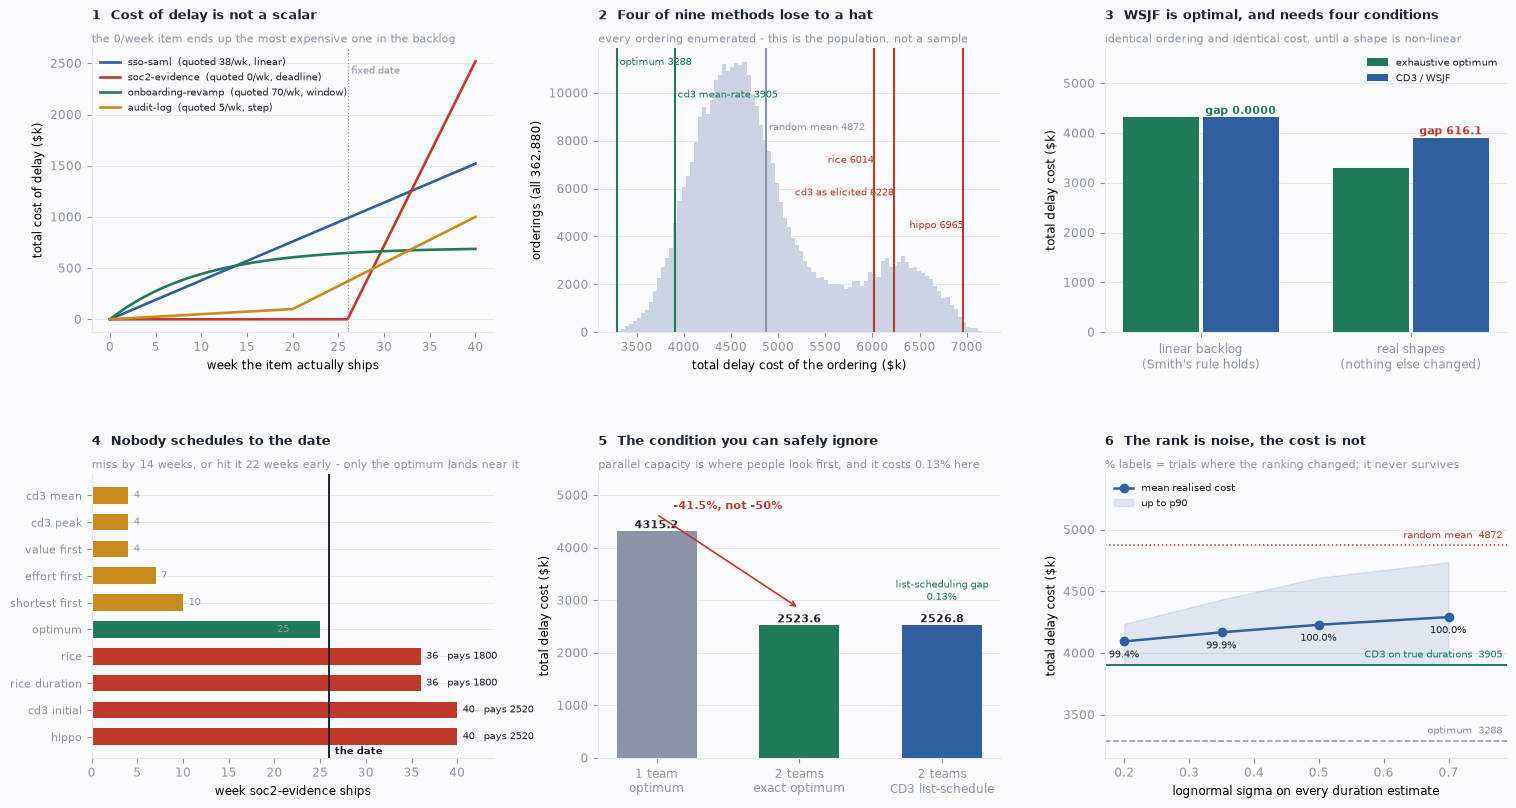

In [14]:
import matplotlib.pyplot as plt
import numpy as np

INK, MUTED, GRID = "#1d2433", "#8b93a7", "#e4e7ee"
BAD, OK, MID, BLUE, FACE = "#c0392b", "#1f7a5a", "#c98a1e", "#2f5f9e", "#fbfbfd"
plt.rcParams.update({"font.size": 8.5, "axes.edgecolor": GRID, "text.color": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.titlesize": 9.5, "axes.titleweight": "bold",
                     "figure.facecolor": FACE, "axes.facecolor": FACE})


def style(ax, title, sub=""):
    ax.set_title(title, loc="left", pad=21 if sub else 6)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=7.6, color=MUTED,
                va="bottom")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRID, lw=0.7)
    ax.set_axisbelow(True)


fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.6))
fig.subplots_adjust(left=0.072, right=0.985, top=0.9, bottom=0.075,
                    wspace=0.26, hspace=0.5)

ax = axes[0][0]
wk = np.linspace(0, 40, 400)
for k, col in (("A", BLUE), ("B", BAD), ("D", OK), ("H", MID)):
    it = ITEMS[k]
    ax.plot(wk, [it.cod.cum(w) for w in wk], color=col, lw=1.9,
            label=f"{it.name}  (quoted {it.cod.rate(0):.0f}/wk, {it.cod.kind})")
ax.axvline(26, color=MUTED, lw=0.9, ls=":")
ax.text(26.4, 2400, "fixed date", fontsize=7, color=MUTED)
ax.set_xlabel("week the item actually ships")
ax.set_ylabel("total cost of delay ($k)")
ax.legend(frameon=False, fontsize=7, loc="upper left")
style(ax, "1  Cost of delay is not a scalar",
      "the 0/week item ends up the most expensive one in the backlog")

ax = axes[0][1]
ax.hist(COSTS, bins=90, color="#ccd3e2", edgecolor="none")
top = ax.get_ylim()[1]
marks = [("optimum", SR["best"], OK),
         ("cd3 mean-rate", cost_of(ORDERINGS["cd3_mean"](ITEMS), ITEMS), OK),
         ("random mean", SR["mean"], MUTED),
         ("rice", cost_of(ORDERINGS["rice"](ITEMS), ITEMS), BAD),
         ("cd3 as elicited", cost_of(ORDERINGS["cd3_initial"](ITEMS), ITEMS), BAD),
         ("hippo", cost_of(ORDERINGS["hippo"](ITEMS), ITEMS), BAD)]
for i, (lbl, v, col) in enumerate(marks):
    ax.axvline(v, color=col, lw=1.5)
    ax.text(v, top * (0.97 - 0.115 * i), f" {lbl} {v:.0f}", fontsize=7, color=col,
            va="top", ha="left" if v < 5200 else "right")
ax.set_xlabel("total delay cost of the ordering ($k)")
ax.set_ylabel(f"orderings (all {len(COSTS):,})")
style(ax, "2  Four of nine methods lose to a hat",
      "every ordering enumerated - this is the population, not a sample")

ax = axes[0][2]
opt = [SL["best"], SR["best"]]
cd3 = [cost_of(ORDERINGS["cd3_mean"](LIN), LIN),
       cost_of(ORDERINGS["cd3_mean"](ITEMS), ITEMS)]
x = np.arange(2)
ax.bar(x - 0.19, opt, 0.36, color=OK, label="exhaustive optimum")
ax.bar(x + 0.19, cd3, 0.36, color=BLUE, label="CD3 / WSJF")
for xi, (o, c) in enumerate(zip(opt, cd3)):
    g = c - o
    ax.text(xi + 0.19, c + 70, f"gap {g:.1f}" if g > 1 else "gap 0.0000", ha="center",
            fontsize=7.6, color=BAD if g > 1 else OK, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["linear backlog\n(Smith's rule holds)",
                    "real shapes\n(nothing else changed)"])
ax.set_ylabel("total delay cost ($k)")
ax.set_ylim(0, 5700)
ax.legend(frameon=False, fontsize=7.4, loc="upper right")
style(ax, "3  WSJF is optimal, and needs four conditions",
      "identical ordering and identical cost, until a shape is non-linear")

ax = axes[1][0]
pairs = sorted([(n, completions(f(ITEMS), ITEMS)["B"]) for n, f in ORDERINGS.items()]
               + [("optimum", completions(SR["best_order"], ITEMS)["B"])],
               key=lambda r: r[1])
names = [n.replace("_", " ") for n, _ in pairs]
fins = [v for _, v in pairs]
ax.barh(range(len(names)), fins, height=0.62,
        color=[BAD if v > 26 else (OK if v > 20 else MID) for v in fins])
ax.axvline(26, color=INK, lw=1.4)
ax.text(26.6, len(names) - 0.35, "the date", fontsize=7.4, color=INK, fontweight="bold")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=7.6)
ax.invert_yaxis()
ax.set_xlabel("week soc2-evidence ships")
ax.set_xlim(0, 44)
for i, v in enumerate(fins):
    pen = ITEMS["B"].cod.cum(v)
    off = -3.4 if names[i] == "optimum" else 0.6
    ax.text(v + off, i, f"{v:.0f}" + (f"   pays {pen:.0f}" if pen else ""), va="center",
            fontsize=7, color=INK if pen else MUTED, ha="right" if off < 0 else "left")
style(ax, "4  Nobody schedules to the date",
      "miss by 14 weeks, or hit it 22 weeks early - only the optimum lands near it")

ax = axes[1][1]
vals = [SL["best"], ex2, gr2]
ax.bar(["1 team\noptimum", "2 teams\nexact optimum", "2 teams\nCD3 list-schedule"],
       vals, color=[MUTED, OK, BLUE], width=0.56)
for i, v in enumerate(vals):
    ax.text(i, v + 55, f"{v:.1f}", ha="center", fontsize=8, fontweight="bold")
ax.annotate("", xy=(1, ex2 + 320), xytext=(0, SL["best"] + 320),
            arrowprops=dict(arrowstyle="->", color=BAD, lw=1.2))
ax.text(0.5, SL["best"] + 420, f"-{100 * (1 - ex2 / SL['best']):.1f}%, not -50%",
        ha="center", fontsize=7.6, color=BAD, fontweight="bold")
ax.text(2, gr2 + 480, f"list-scheduling gap\n{100 * (gr2 / ex2 - 1):.2f}%", ha="center",
        fontsize=7.4, color=OK)
ax.set_ylabel("total delay cost ($k)")
ax.set_ylim(0, 5400)
style(ax, "5  The condition you can safely ignore",
      "parallel capacity is where people look first, and it costs 0.13% here")

ax = axes[1][2]
truth = RES[0]["truth_cost"]
ax.plot(SIGMAS, [r["mean"] for r in RES], "o-", color=BLUE, lw=1.8,
        label="mean realised cost")
ax.fill_between(SIGMAS, [truth] * 4, [r["p90"] for r in RES], color=BLUE, alpha=0.13,
                label="up to p90")
for y, txt, col in ((truth, f"CD3 on true durations  {truth:.0f}", OK),
                    (SR["best"], f"optimum  {SR['best']:.0f}", MUTED),
                    (SR["mean"], f"random mean  {SR['mean']:.0f}", BAD)):
    ax.axhline(y, color=col, lw=1.4 if col == OK else 1.1,
               ls="-" if col == OK else ("--" if col == MUTED else ":"))
    ax.text(0.783, y + 40, txt, fontsize=7, color=col, va="bottom", ha="right")
for s, r in zip(SIGMAS, RES):
    ax.text(s, r["mean"] - 130, f"{100 * r['reorder_rate']:.1f}%", ha="center",
            fontsize=7, color=INK)
ax.set_xlim(0.17, 0.79)
ax.set_ylim(3150, 5450)
ax.set_xlabel("lognormal sigma on every duration estimate")
ax.set_ylabel("total delay cost ($k)")
ax.legend(frameon=False, fontsize=7.1, loc="upper left")
style(ax, "6  The rank is noise, the cost is not",
      "% labels = trials where the ranking changed; it never survives")

fig.savefig("notebook_cod.png", dpi=140, facecolor=FACE, bbox_inches="tight")
plt.show()

## 12. What survives

1. **An ordering is not a schedule.** Score the schedule. Any method that stops at
   a ranked list has not yet produced a number you can compare to anything.
2. **Cost of delay is a rate over time.** A scalar throws away the shape, and the
   shape is where the deadlines and the closing windows live. The item quoted at
   0/week is the most expensive one in this backlog.
3. **WSJF is exactly optimal under Smith's rule** — reproduced here to a gap of
   0.0000 against a full enumeration — and every one of its four conditions is
   violated by an ordinary backlog.
4. **"CD3" does not name an ordering.** Three defensible elicitations of the same
   input disagree about 18 of 36 pairs and span the 90th to the 5.4th percentile
   of all orderings. The elicitation, not the method name, is the decision.
5. **Four of nine orderings are beaten by the mean of all 362,880.** RICE by 23%.
   HiPPO sits at the 99.8th percentile: near the worst ordering available.
6. **Nobody schedules to the date.** The optimum holds it with one week of slack.
   Every method misses by 14 weeks or hits it 22 weeks early.
7. **Parallel capacity is the condition you can safely ignore** (0.13% here) and
   it is the one people reach for first. Doubling teams buys 41.5%, not 50%.
8. **The rank is noise. The cost is the number to report.** At an ordinary estimate
   error the ranking changes in 99.9% of trials while the cost it delivers moves
   less than the gap between two methods.

### What to actually do on Monday

- Write cost of delay as **two numbers and a shape** — a rate, a date, and which of
  the four shapes it is — not one number per item.
- Score the **schedule** your order implies, and put that number next to the order.
  It is the only output that survives re-estimation.
- Elicit cost of delay **the same way every time** and write the convention down;
  the convention is worth more than the method.
- Handle fixed dates as **constraints**, not high scores. A date is not a priority.
- Do **not** build the parallel-assignment optimiser.

In [15]:
# ---------------------------------------------------------------- TRY YOUR OWN
# Replace the backlog with yours. Duration is CALENDAR weeks for one team;
# person_weeks is effort. Cost of delay needs a shape, not just a rate.
#
# MY_ITEMS = {
#     "X": Item("X", "my-thing", duration=5, person_weeks=8,
#               cod=CoD("linear", r=25.0),
#               reach=500, impact=2.0, confidence=0.8),
#     "Y": Item("Y", "the-audit", duration=3, person_weeks=3,
#               cod=CoD("deadline", r2=200.0, t_break=18.0),   # a real date
#               reach=100, impact=3.0, confidence=1.0),
#     "Z": Item("Z", "market-window", duration=4, person_weeks=4,
#               cod=CoD("window", r=60.0, tau=12.0),           # closes on you
#               reach=900, impact=1.0, confidence=0.6),
# }
#
# S = sweep(MY_ITEMS)                       # exhaustive up to ~10 items
# for name, f in ORDERINGS.items():
#     o = f(MY_ITEMS)
#     print(f"{name:15} {''.join(o)}  {cost_of(o, MY_ITEMS):9.1f}")
# print(f"{'OPTIMUM':15} {''.join(S['best_order'])}  {S['best']:9.1f}")
# print(f"{'random mean':15} {'':9}  {S['mean']:9.1f}")
#
# Past ~10 items the enumeration stops being free. Two options that stay honest:
#   - sample orderings for the random baseline instead of enumerating them
#   - keep CD3 as the ordering, but keep scoring the schedule it produces
print("Edit the cell above and re-run. Nothing here needs a key or a network.")

Edit the cell above and re-run. Nothing here needs a key or a network.


---

**[Cost of Delay](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/cost-of-delay)** — Day 158 of
[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder).

Run the interactive version:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Reproduce every number in the README from the command line:

```bash
python3 evidence.py
python3 -m pytest test_codelay.py -q
```